In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)  # Remove timezone
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()

# Compute average demand per hour per year
avg_by_hour_year = df.groupby(['Year', 'Hour'])['Total Demand'].mean().reset_index()

# Average demand across all years
avg_by_hour = df.groupby('Hour')['Total Demand'].mean().reset_index()



CSV files loaded


In [10]:
# Start making model for the graph above

# Data Seperation as X and Y

x = df[['Datetime']].copy()
x['Hour'] = x['Datetime'].dt.hour
x = x[['Hour']]  # keep only hour as feature

y = df['Total Demand']

#Data splitting

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=100)


#print(len(X_train)) # 80% of data size

#print(len(X_test)) # 20% of data size

#print(len(x)) # Original Data size


In [11]:
# Model Building with Random forest

# Training the model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, Y_train)

# Applying the model to make a prediction

y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

# Model performance
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(Y_train, y_rf_train_pred)
rf_train_r2 = r2_score(Y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(Y_test, y_rf_test_pred)
rf_test_r2 = r2_score(Y_test, y_rf_test_pred)

plot_df = pd.DataFrame({
    "Hour": X_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

rf_results = pd.DataFrame(["Random forest", rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ["Method", "Training MSE", "Training R2", "Test MSE", "Test R2"]
print(rf_results)


          Method   Training MSE Training R2       Test MSE   Test R2
0  Random forest  516687.159155    0.343202  521185.545247  0.341412


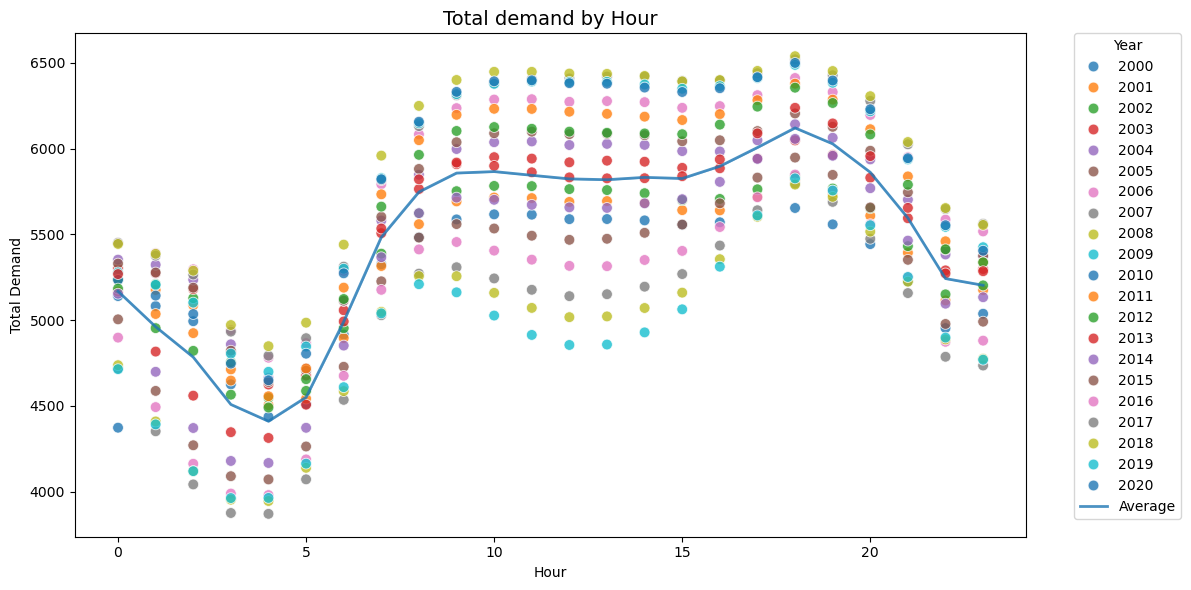

In [15]:
# Model Comparison

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build a DataFrame with actual vs predicted
plot_df = pd.DataFrame({
    "Hour": X_test.values.flatten(),
    "Actual_Demand": Y_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

plt.figure(figsize=(12, 6))

# Scatter plot of actual averages
sns.scatterplot(
    data=avg_by_hour_year,
    x="Hour",
    y="Total Demand",
    hue="Year",
    palette="tab10",
    s=60,
    alpha=0.8
)

# Line plot of predicted demand
sns.lineplot(
    data=plot_df,
    x="Hour",
    y="Predicted_Demand",
    linewidth=2,
    alpha=0.8,
    label="Average"
)


# Title & labels
plt.title("Total demand by Hour", fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Total Demand")

# ✅ Move legend outside the plot
plt.legend(
    title="Year",
    bbox_to_anchor=(1.05, 1),   # position legend outside
    loc="upper left",           # anchor it to the upper left corner
    borderaxespad=0
)

plt.tight_layout()  # adjust padding so labels/legend don’t get cut
plt.show()


CSV files loaded


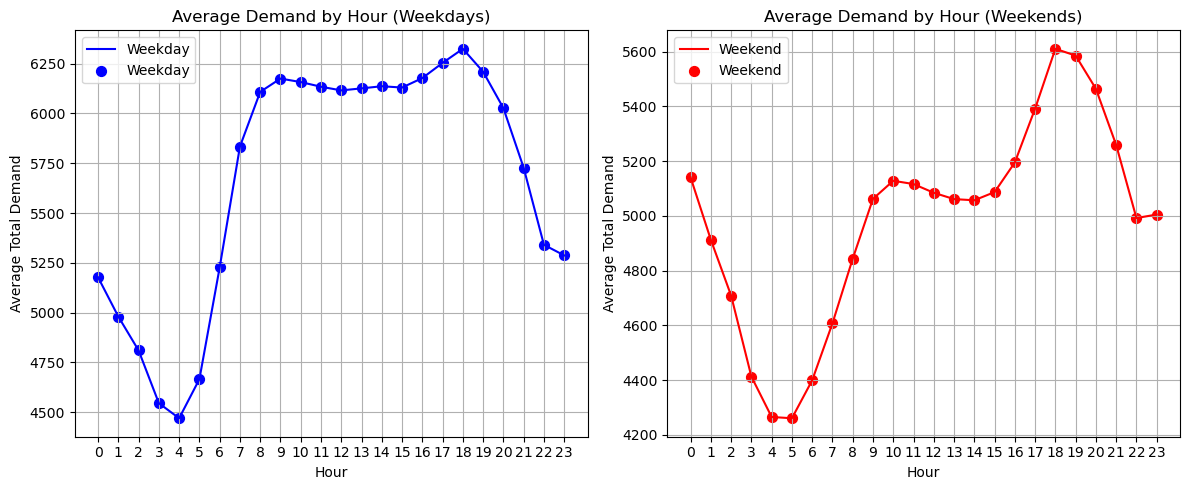

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Select demand for Victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)  # Remove timezone
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

# Extract day name
df['Day'] = df['Datetime'].dt.day_name()

# Classify as weekday or weekend
df['Is_Weekend'] = df['Day'].isin(['Saturday', 'Sunday'])

# Compute average demand by hour for weekdays and weekends
avg_by_hour_daytype = df.groupby(['Is_Weekend', 'Hour'])['Total Demand'].mean().reset_index()

# Split into weekdays and weekends
avg_weekdays = avg_by_hour_daytype[avg_by_hour_daytype['Is_Weekend'] == False]
avg_weekends = avg_by_hour_daytype[avg_by_hour_daytype['Is_Weekend'] == True]

# Create two separate plots
plt.figure(figsize=(12, 5))

# Plot 1: Average demand by hour for weekdays
plt.subplot(1, 2, 1)
plt.plot(avg_weekdays['Hour'], avg_weekdays['Total Demand'], label='Weekday', color='blue')
plt.title('Average Demand by Hour (Weekdays)')
plt.xlabel('Hour')
plt.ylabel('Average Total Demand')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(avg_weekends['Hour'], avg_weekends['Total Demand'], label='Weekend', color='red')
plt.title('Average Demand by Hour (Weekends)')
plt.xlabel('Hour')
plt.ylabel('Average Total Demand')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 1)
plt.scatter(avg_weekdays['Hour'], avg_weekdays['Total Demand'], label='Weekday', color='blue', s=50)  # s=50 for point size
plt.title('Average Demand by Hour (Weekdays)')
plt.xlabel('Hour')
plt.ylabel('Average Total Demand')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()

# Plot 2: Average demand by hour for weekends
plt.subplot(1, 2, 2)
plt.scatter(avg_weekends['Hour'], avg_weekends['Total Demand'], label='Weekend', color='red', s=50)  # s=50 for point size
plt.title('Average Demand by Hour (Weekends)')
plt.xlabel('Hour')
plt.ylabel('Average Total Demand')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()

# Adjust layout and show plots
plt.tight_layout()
plt.show()

CSV files loaded
Mean Squared Error: 555244.49
Mean Absolute Error: 591.55


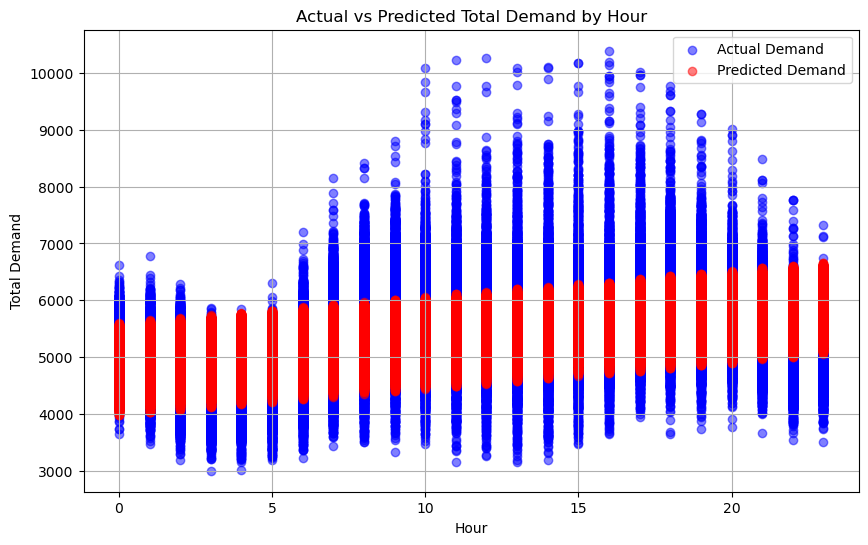

Predicted Demand for 2025-10-13 15:25 (Monday): 5220.10


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Select demand for Victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)  # Remove timezone
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract features
df['Hour'] = df['Datetime'].dt.hour
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day_name()  # Day as string (e.g., "Monday")
df['Is_Weekend'] = df['Day'].isin(['Saturday', 'Sunday'])

# Prepare features and target
# One-hot encode the 'Day' column
encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' to avoid multicollinearity
day_encoded = encoder.fit_transform(df[['Day']])
day_encoded_df = pd.DataFrame(day_encoded, columns=encoder.get_feature_names_out(['Day']))

# Combine encoded days with other features
X = pd.concat([df[['Hour', 'Year', 'Month', 'Is_Weekend']].reset_index(drop=True), day_encoded_df], axis=1)
y = df['Total Demand']

# Handle any missing values
df = df.dropna(subset=['Hour', 'Year', 'Month', 'Is_Weekend', 'Total Demand'])
X = X.dropna()
y = y[X.index]  # Align y with X after dropping NaN

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(X_test['Hour'], y_test, color='blue', label='Actual Demand', alpha=0.5)
plt.scatter(X_test['Hour'], y_pred, color='red', label='Predicted Demand', alpha=0.5)
plt.title('Actual vs Predicted Total Demand by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Demand')
plt.legend()
plt.grid(True)
plt.show()

# Example prediction for a specific date and time (e.g., today: 2025-10-13, 15:25)
new_data = pd.DataFrame({
    'Hour': [15],  # Current hour (3:25 PM = 15)
    'Year': [2025],  # Current year
    'Month': [10],  # Current month
    'Is_Weekend': [False]  # Today is Monday, not a weekend
})
# Encode the day for the new data
new_day_encoded = encoder.transform(pd.DataFrame({'Day': ['Monday']}))
new_day_encoded_df = pd.DataFrame(new_day_encoded, columns=encoder.get_feature_names_out(['Day']))
new_data = pd.concat([new_data.reset_index(drop=True), new_day_encoded_df], axis=1)

predicted_demand = model.predict(new_data)
print(f"Predicted Demand for 2025-10-13 15:25 (Monday): {predicted_demand[0]:.2f}")